In [54]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow import keras

In [55]:
# Define column names (1 letter + 16 features)
columns = ["letter"] + [f"x{i}" for i in range(1, 17)]

df = pd.read_csv("2_letter-recognition.data", header=None, names=columns)

print(df.head())
print("Shape:", df.shape)

  letter  x1  x2  x3  x4  x5  x6  x7  x8  x9  x10  x11  x12  x13  x14  x15  \
0      T   2   8   3   5   1   8  13   0   6    6   10    8    0    8    0   
1      I   5  12   3   7   2  10   5   5   4   13    3    9    2    8    4   
2      D   4  11   6   8   6  10   6   2   6   10    3    7    3    7    3   
3      N   7  11   6   6   3   5   9   4   6    4    4   10    6   10    2   
4      G   2   1   3   1   1   8   6   6   6    6    5    9    1    7    5   

   x16  
0    8  
1   10  
2    9  
3    8  
4   10  
Shape: (20000, 17)


In [56]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [57]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(16,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(26, activation='softmax')
])

c:\Users\Aditya.konde\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5548 - loss: 1.5382 - val_accuracy: 0.7300 - val_loss: 0.9030
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7930 - loss: 0.6988 - val_accuracy: 0.8125 - val_loss: 0.6225
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8412 - loss: 0.5214 - val_accuracy: 0.8606 - val_loss: 0.4770
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8716 - loss: 0.4193 - val_accuracy: 0.8694 - val_loss: 0.4193
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8951 - loss: 0.3497 - val_accuracy: 0.8881 - val_loss: 0.3512
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9084 - loss: 0.2959 - val_accuracy: 0.9081 - val_loss: 0.3009
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9217 - loss: 0.2561 - val_accuracy: 0.9169 - val_loss: 0.2685
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9299 - loss: 0.2259 - val_accuracy: 0.

In [63]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9495 - loss: 0.1933
Test Loss: 0.19328932464122772
Test Accuracy: 0.9495000243186951


In [64]:
predictions = model.predict(X_test)

for i in range(5):
    pred_class = np.argmax(predictions[i])
    
    predicted_letter = encoder.inverse_transform([pred_class])[0]
    actual_letter = encoder.inverse_transform([y_test[i]])[0]
    
    print("Actual:", actual_letter, "Predicted:", predicted_letter)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Actual: T Predicted: T
Actual: L Predicted: L
Actual: A Predicted: A
Actual: E Predicted: E
Actual: Q Predicted: Q


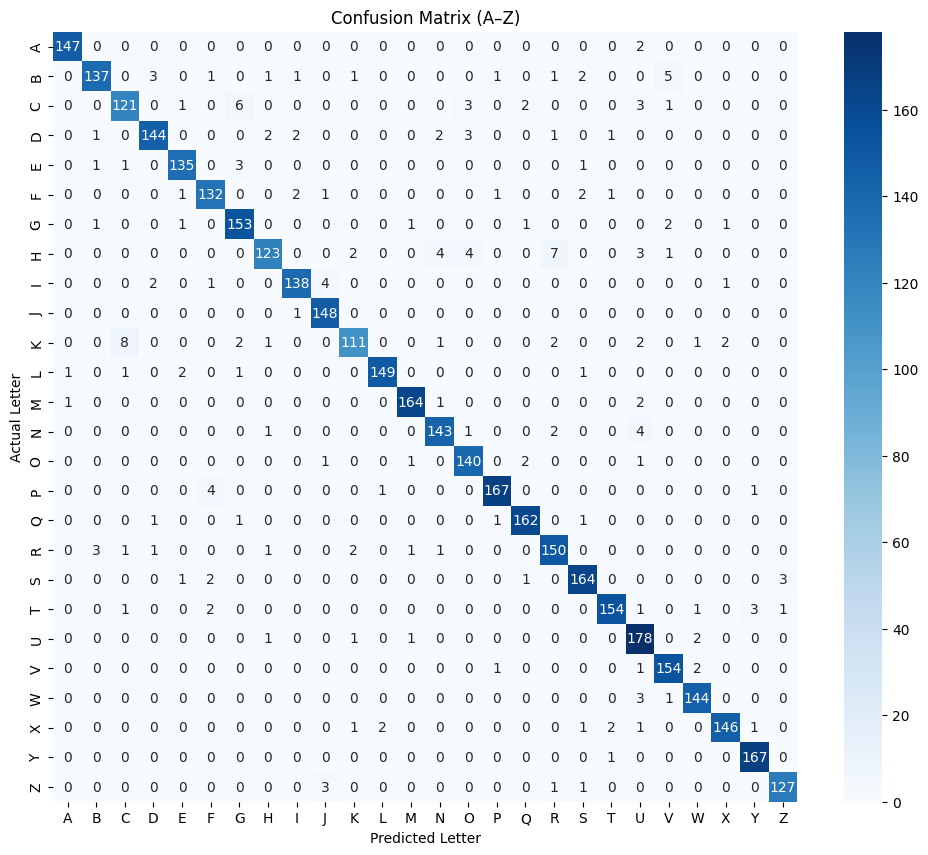

In [65]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions for all test samples
all_predictions = predictions
pred_classes = np.argmax(all_predictions, axis=1)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

labels = encoder.classes_

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Letter")
plt.ylabel("Actual Letter")
plt.title("Confusion Matrix (A–Z)")

plt.show()